# 🚀 Tercera Entrega: Modelado y Evaluación
Este notebook construye y evalúa 4 modelos de clasificación binaria para predecir la dirección de diferentes clases de activos (`Índices`, `Cripto`, `Forex`, `Commodities`) en respuesta a sorpresas macroeconómicas extremas.

---
## Parte 1: Preparación del Dataset para Modelado
En esta sección, cargamos el dataset original de la Entrega 1 y le aplicamos las funciones de cómputo clave desarrolladas en la Entrega 2 (EDA) para generar todas nuestras features y targets.

### 1.1 Importaciones y Carga de Datos
Importamos las librerías necesarias y cargamos el dataset `correlacion_final_2025-09-24.csv`.

In [23]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ID de Google Drive del archivo CSV original
GDRIVE_ID = "13nwMTNpjO6xtp1osCRDfa7wGoRjm30fa"
NOMBRE_ARCHIVO = "correlacion_final_2025-09-24.csv"

# Descargar solo si el archivo no existe
if not os.path.exists(NOMBRE_ARCHIVO):
    print(f"Archivo '{NOMBRE_ARCHIVO}' no encontrado. Descargando de Google Drive...")
    !gdown --id {GDRIVE_ID} -O {NOMBRE_ARCHIVO}

try:
    # Cargar el CSV
    df = pd.read_csv(NOMBRE_ARCHIVO)
    print(f"\n✅ Dataset '{NOMBRE_ARCHIVO}' cargado exitosamente.")
    print(f"Forma inicial: {df.shape}")

    # --- Conversión de Fechas (¡CRUCIAL!) ---
    # Convertimos la columna 'fecha' a datetime para el split cronológico
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    df = df.dropna(subset=['fecha']) # Eliminar filas sin fecha válida
    df = df.sort_values(by='fecha') # Asegurar orden cronológico

    df.info()

except FileNotFoundError:
    print(f"❌ Error: No se pudo cargar el archivo '{NOMBRE_ARCHIVO}'.")
    df = None


✅ Dataset 'correlacion_final_2025-09-24.csv' cargado exitosamente.
Forma inicial: (1436, 71)
<class 'pandas.core.frame.DataFrame'>
Index: 1436 entries, 1264 to 200
Data columns (total 71 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 1436 non-null   datetime64[ns]
 1   hora                  1436 non-null   object        
 2   actual                1436 non-null   float64       
 3   forecast              1384 non-null   float64       
 4   previo                1436 non-null   float64       
 5   source_file           1436 non-null   object        
 6   BRENTCMDUSD_open      1020 non-null   float64       
 7   BRENTCMDUSD_high      1020 non-null   float64       
 8   BRENTCMDUSD_low       1020 non-null   float64       
 9   BRENTCMDUSD_close     1020 non-null   float64       
 10  BRENTCMDUSD_volume    1020 non-null   float64       
 11  BTCUSD_open           688 non-null    float

### 1.2 Funciones de Cómputo (Extraídas del EDA)
Aquí definimos las funciones que necesitamos de nuestro notebook de EDA (`segundaentregaproyectofinal.py`) para calcular métricas de velas, sorpresas estandarizadas y magnitud.

In [24]:
"""
Contiene las funciones clave extraídas del EDA (Entrega 2)
para procesar el DataFrame crudo.
"""

def parse_numeric_value(value):
    """
    Función auxiliar para limpiar y convertir valores monetarios/porcentaje
    (ej. '3.5%', '110K', '2.1M') a números.
    """
    if isinstance(value, str):
        value = value.strip().replace('%', '').replace('K', 'e3').replace('M', 'e6').replace('B', 'e9')
    return pd.to_numeric(value, errors='coerce')

def calcular_metricas_ampliadas(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    (De EDA Sección 2)
    Toma el DataFrame ancho y, para cada activo, calcula:
    1. Retorno del cuerpo (%): 'activo_retorno_cuerpo_pct'
    2. Rango total (%): 'activo_rango_total_pct'
    3. Ratio mecha superior: 'activo_mecha_superior_ratio'
    4. Ratio mecha inferior: 'activo_mecha_inferior_ratio'
    """
    df = df_input.copy()

    # Identificar los prefijos de los activos
    activos_base = sorted(list(set(col.split('_')[0] for col in df.columns if '_open' in col)))
    if not activos_base:
        print("❌ Error en calcular_metricas_ampliadas: No se encontraron columnas '_open'.")
        return df_input

    print(f"Calculando métricas de vela para {len(activos_base)} activos...")

    for activo in activos_base:
        col_open = f'{activo}_open'
        col_high = f'{activo}_high'
        col_low = f'{activo}_low'
        col_close = f'{activo}_close'

        if all(c in df.columns for c in [col_open, col_high, col_low, col_close]):
            # Calcular métricas
            df[f'{activo}_retorno_cuerpo_pct'] = ((df[col_close] - df[col_open]) / df[col_open]) * 100
            df[f'{activo}_rango_total_pct'] = ((df[col_high] - df[col_low]) / df[col_open]) * 100

            rango_vela_abs = df[col_high] - df[col_low]
            mecha_superior = df[col_high] - np.maximum(df[col_open], df[col_close])
            mecha_inferior = np.minimum(df[col_open], df[col_close]) - df[col_low]

            df[f'{activo}_mecha_superior_ratio'] = np.where(rango_vela_abs > 0, mecha_superior / rango_vela_abs, 0)
            df[f'{activo}_mecha_inferior_ratio'] = np.where(rango_vela_abs > 0, mecha_inferior / rango_vela_abs, 0)

    print("✅ Métricas de vela calculadas.")
    return df

def agregar_variables_estandarizadas(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    (De EDA Sección 4.1)
    Calcula 'sorpresa' (Actual vs Forecast) y la estandariza (Z-Score)
    para cada tipo de noticia, creando 'sorpresa_std'.
    """
    df = df_input.copy()
    print("Calculando 'sorpresa_std'...")

    if 'actual' in df.columns and 'forecast' in df.columns:
        df['actual_numeric'] = df['actual'].apply(parse_numeric_value)
        df['forecast_numeric'] = df['forecast'].apply(parse_numeric_value)
        df['sorpresa'] = df['actual_numeric'] - df['forecast_numeric']

        # Estandarizar 'sorpresa' (Z-Score) agrupando por noticia
        df['sorpresa_std'] = df.groupby('noticia')['sorpresa'].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
        )
    else:
        print("⚠️ Advertencia: Faltan columnas 'actual' o 'forecast'.")
        return df_input

    print("✅ 'sorpresa_std' calculada.")
    return df

def segmentar_por_magnitud(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    (De EDA Sección 5.1)
    Segmenta 'sorpresa_std' en 4 cuartiles para crear la variable
    categórica 'magnitud_sorpresa'.
    """
    df = df_input.copy()
    print("Segmentando 'magnitud_sorpresa'...")

    if 'sorpresa_std' not in df.columns:
        print("❌ Error: Se requiere la columna 'sorpresa_std' para segmentar.")
        return df_input

    try:
        df['magnitud_sorpresa'] = pd.qcut(
            df['sorpresa_std'],
            q=4,
            labels=['Negativa Extrema', 'Negativa Moderada', 'Positiva Moderada', 'Positiva Extrema']
        )
    except ValueError as e:
        print(f"⚠️ Advertencia al segmentar en cuartiles: {e}. Puede haber datos insuficientes.")
        df['magnitud_sorpresa'] = pd.NA

    print("✅ 'magnitud_sorpresa' segmentada.")
    return df

### 1.3 Pipeline de Preparación y Creación de Targets
Ejecutamos las funciones en orden, creamos nuestras 4 variables `target` y filtramos el dataset, quedándonos solo con los eventos de sorpresa extrema.

In [25]:
if df is not None:
    print("--- Iniciando Pipeline de Preparación de Datos ---")

    # 1. Crear columna 'noticia' (necesaria para los cálculos)
    df['noticia'] = df['source_file'].str.replace('.csv', '', regex=False).str.replace('_', ' ').str.title()

    # 2. Calcular métricas de vela
    df_procesado = calcular_metricas_ampliadas(df)

    # 3. Calcular sorpresas estandarizadas
    df_procesado = agregar_variables_estandarizadas(df_procesado)

    # 4. Segmentar por magnitud de sorpresa
    df_procesado = segmentar_por_magnitud(df_procesado)

    print("\n--- Creando Variables Target ---")

    # 5. Definir las 4 variables objetivo (TARGETS)
    activos_target = {
        'target_Indices': 'USA500IDXUSD_retorno_cuerpo_pct',
        'target_Cripto': 'BTCUSD_retorno_cuerpo_pct',
        'target_Forex': 'EURUSD_retorno_cuerpo_pct',
        'target_Commodities': 'XAUUSD_retorno_cuerpo_pct'
    }

    for target_name, col_retorno in activos_target.items():
        if col_retorno in df_procesado.columns:
            # 1 si el retorno fue > 0 (Alcista), 0 si fue <= 0 (Bajista)
            df_procesado[target_name] = (df_procesado[col_retorno] > 0).astype(int)
            print(f"✅ Target '{target_name}' creado.")
        else:
            print(f"❌ Error: No se encontró la columna '{col_retorno}' para crear el target.")

    print("\n--- Filtrando por Sorpresas Extremas ---")

    # 6. Filtrar el dataset (Alcance del Modelo)
    df_final_modelo = df_procesado[
        df_procesado['magnitud_sorpresa'].isin(['Negativa Extrema', 'Positiva Extrema'])
    ].copy()

    # Es crucial que las categorías no usadas se eliminen
    if pd.api.types.is_categorical_dtype(df_final_modelo['magnitud_sorpresa']):
        df_final_modelo['magnitud_sorpresa'] = df_final_modelo['magnitud_sorpresa'].cat.remove_unused_categories()

    print(f"Tamaño del dataset original: {len(df_procesado)} filas")
    print(f"Tamao del dataset filtrado (eventos extremos): {len(df_final_modelo)} filas")

    print("\n--- Resumen del Dataset Final para Modelado ---")
    cols_a_chequear = list(activos_target.keys()) + ['magnitud_sorpresa', 'sorpresa_std', 'noticia', 'fecha']
    print(df_final_modelo[cols_a_chequear].info())

    print("\nDistribución de clases (Targets) en eventos extremos:")
    for target in activos_target.keys():
        if target in df_final_modelo.columns:
            print(f"\n{target}:")
            print(df_final_modelo[target].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

else:
    print("❌ El DataFrame 'df' no se cargó. No se puede continuar.")

--- Iniciando Pipeline de Preparación de Datos ---
Calculando métricas de vela para 13 activos...
✅ Métricas de vela calculadas.
Calculando 'sorpresa_std'...
✅ 'sorpresa_std' calculada.
Segmentando 'magnitud_sorpresa'...
✅ 'magnitud_sorpresa' segmentada.

--- Creando Variables Target ---
✅ Target 'target_Indices' creado.
✅ Target 'target_Cripto' creado.
✅ Target 'target_Forex' creado.
✅ Target 'target_Commodities' creado.

--- Filtrando por Sorpresas Extremas ---
Tamaño del dataset original: 1436 filas
Tamao del dataset filtrado (eventos extremos): 696 filas

--- Resumen del Dataset Final para Modelado ---
<class 'pandas.core.frame.DataFrame'>
Index: 696 entries, 797 to 1265
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   target_Indices      696 non-null    int64         
 1   target_Cripto       696 non-null    int64         
 2   target_Forex        696 non-null    int64         
 3  

### 1.4 Guardado del Dataset Final
Guardamos este DataFrame procesado y filtrado en un archivo Parquet. Este será el **único** archivo que necesitaremos para el resto del notebook.

In [26]:
# CELDA 8 (MODIFICADA)

if 'df_final_modelo' in locals() and 'df_procesado' in locals():

    # --- 1. Guardado para Entrega 3 (Esto es lo que ya tenías) ---
    archivo_para_modelado = 'dataset_para_modelado.parquet'
    df_final_modelo.to_parquet(archivo_para_modelado, index=False)
    print(f"✅ (Para Entrega 3) DataFrame FILTRADO guardado como '{archivo_para_modelado}'.")

    # --- 2. Guardado NUEVO para Entrega 4 (Streamlit) ---
    archivo_completo = 'dataset_completo_procesado.parquet'
    df_procesado.to_parquet(archivo_completo, index=False)
    print(f"✅ (Para Entrega 4) DataFrame COMPLETO guardado como '{archivo_completo}'.")

    print("--- Fin de la Parte 1 (Preparación) ---")

else:
    print("❌ No se generó 'df_final_modelo' o 'df_procesado'. No se guardó ningún archivo.")

✅ (Para Entrega 3) DataFrame FILTRADO guardado como 'dataset_para_modelado.parquet'.
✅ (Para Entrega 4) DataFrame COMPLETO guardado como 'dataset_completo_procesado.parquet'.
--- Fin de la Parte 1 (Preparación) ---


---
## Parte 2: Modelado (Inicio del Trabajo)
---
**A partir de aquí comienza la Tercera Entrega.**

Cargamos el archivo `dataset_para_modelado.parquet` que acabamos de crear. Este `df_modelo` está limpio, filtrado y listo para el `train_test_split` y el `Pipeline` de `sklearn`.

### 2.1 Carga del Dataset Limpio y Librerías de Modelado

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

# --- Cargar el dataset final ---
archivo_para_modelado = 'dataset_para_modelado.parquet'

if os.path.exists(archivo_para_modelado):
    df_modelo = pd.read_parquet(archivo_para_modelado)
    print(f"✅ Dataset '{archivo_para_modelado}' cargado exitosamente.")
    print(f"Forma: {df_modelo.shape}")
    print("\nColumnas listas para el modelado:")
    print(df_modelo.info())
else:
    print(f"❌ Error: No se encontró '{archivo_para_modelado}'.")
    print("Asegúrate de ejecutar la 'Parte 1' de este notebook primero.")

✅ Dataset 'dataset_para_modelado.parquet' cargado exitosamente.
Forma: (696, 133)

Columnas listas para el modelado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Columns: 133 entries, fecha to target_Commodities
dtypes: category(1), datetime64[ns](1), float64(124), int64(4), object(3)
memory usage: 718.7+ KB
None


### 2.2 Definición de Features (X) y Targets (Y)
Separamos nuestras variables predictoras (`X`) de nuestras 4 variables objetivo (`Y`).

In [28]:
if 'df_modelo' in locals():
    # --- Definir las 4 VARIABLES OBJETIVO (Y) ---
    TARGET_COLS = [
        'target_Indices',
        'target_Cripto',
        'target_Forex',
        'target_Commodities'
    ]

    Y = df_modelo[TARGET_COLS]

    # --- Definir las VARIABLES PREDICTORAS (X) ---

    # 1. Features Globales (comunes a todos los modelos)
    FEATURES_GLOBALES_NUM = ['sorpresa_std']
    FEATURES_GLOBALES_CAT = ['magnitud_sorpresa', 'noticia']

    # 2. Features Específicas (ratios de mechas para cada activo)
    # Seleccionamos solo las de los activos que nos interesan
    FEATURES_ESPECIFICAS_NUM = [
        'USA500IDXUSD_mecha_superior_ratio', 'USA500IDXUSD_mecha_inferior_ratio',
        'BTCUSD_mecha_superior_ratio', 'BTCUSD_mecha_inferior_ratio',
        'EURUSD_mecha_superior_ratio', 'EURUSD_mecha_inferior_ratio',
        'XAUUSD_mecha_superior_ratio', 'XAUUSD_mecha_inferior_ratio'
    ]

    # Agrupamos por tipo para el Pipeline
    NUMERIC_FEATURES = FEATURES_GLOBALES_NUM + FEATURES_ESPECIFICAS_NUM
    CATEGORICAL_FEATURES = FEATURES_GLOBALES_CAT

    # Juntamos todas las features
    FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

    X = df_modelo[FEATURE_COLS]

    # También guardamos la fecha para el split
    fechas = df_modelo['fecha']

    print("Variables predictoras (X):")
    print(X.info())
    print("\nVariables objetivo (Y):")
    print(Y.info())

Variables predictoras (X):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   sorpresa_std                       696 non-null    float64 
 1   USA500IDXUSD_mecha_superior_ratio  696 non-null    float64 
 2   USA500IDXUSD_mecha_inferior_ratio  696 non-null    float64 
 3   BTCUSD_mecha_superior_ratio        696 non-null    float64 
 4   BTCUSD_mecha_inferior_ratio        696 non-null    float64 
 5   EURUSD_mecha_superior_ratio        696 non-null    float64 
 6   EURUSD_mecha_inferior_ratio        696 non-null    float64 
 7   XAUUSD_mecha_superior_ratio        696 non-null    float64 
 8   XAUUSD_mecha_inferior_ratio        696 non-null    float64 
 9   magnitud_sorpresa                  696 non-null    category
 10  noticia                            696 non-null    object  
dtypes: category(1), fl

### 2.3 Split Cronológico (Train/Test Split)
**Este es un paso crítico.** No usamos un split aleatorio. Particionamos los datos por fecha para simular un escenario real de trading, evitando *data leakage*.

In [29]:
if 'X' in locals() and 'Y' in locals():
    # Definimos el tamaño del set de test (ej. 20%)
    TEST_SIZE = 0.2

    # Calculamos el índice de corte basado en el tiempo
    split_index = int(len(X) * (1 - TEST_SIZE))

    # Realizamos el corte cronológico
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    Y_train = Y.iloc[:split_index]
    Y_test = Y.iloc[split_index:]

    fechas_train = fechas.iloc[:split_index]
    fechas_test = fechas.iloc[split_index:]

    print("--- Split Cronológico Realizado ---")
    print(f"Total de datos: {len(X)} eventos")
    print(f"Datos de Train: {len(X_train)} eventos")
    print(f"Datos de Test: {len(X_test)} eventos")
    print(f"\nPeríodo de Train: {fechas_train.min()} a {fechas_train.max()}")
    print(f"Período de Test:  {fechas_test.min()} a {fechas_test.max()}")

--- Split Cronológico Realizado ---
Total de datos: 696 eventos
Datos de Train: 556 eventos
Datos de Test: 140 eventos

Período de Train: 2009-01-06 00:00:00 a 2022-05-12 00:00:00
Período de Test:  2022-06-03 00:00:00 a 2025-08-14 00:00:00


## 3. Construcción del Pipeline de Preprocesamiento

Ahora creamos el `ColumnTransformer`, que es el corazón de nuestro preprocesamiento.

Este transformador aplicará:
1.  **`numeric_pipeline`:** Imputación (con mediana) y escalado (`StandardScaler`) a todas nuestras features numéricas (`sorpresa_std` y los 8 ratios de mechas).
2.  **`categorical_pipeline`:** Imputación (con valor más frecuente) y codificación (`OneHotEncoder`) a nuestras features categóricas (`noticia` y `magnitud_sorpresa`).

Esto nos asegura que no hay *data leakage*, ya que el `fit` (cálculo de la mediana, media, desv. estándar, etc.) se hará **solo** sobre `X_train`.

In [30]:
if 'X_train' in locals():
    # 1. Pipeline para variables NUMÉRICAS
    # Imputamos con la mediana (robusto a outliers) y escalamos
    numeric_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # 2. Pipeline para variables CATEGÓRICAS
    # Imputamos con el más frecuente y aplicamos One-Hot Encoding
    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # 3. Crear el ColumnTransformer
    # Usamos las listas de columnas que definimos en la Celda 12
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, NUMERIC_FEATURES),
            ('cat', categorical_pipeline, CATEGORICAL_FEATURES)
        ],
        remainder='drop' # Ignora cualquier otra columna que no hayamos listado
    )

    print("✅ Preprocessor (ColumnTransformer) creado exitosamente.")
    print("\nFeatures numéricas que serán procesadas:")
    print(NUMERIC_FEATURES)
    print("\nFeatures categóricas que serán procesadas:")
    print(CATEGORICAL_FEATURES)

    # Opcional: Probar el preprocesador
    print("\nProbando el 'fit_transform' en X_train...")
    X_train_transformed = preprocessor.fit_transform(X_train)
    print(f"Forma original de X_train: {X_train.shape}")
    print(f"Forma transformada de X_train: {X_train_transformed.shape}")

✅ Preprocessor (ColumnTransformer) creado exitosamente.

Features numéricas que serán procesadas:
['sorpresa_std', 'USA500IDXUSD_mecha_superior_ratio', 'USA500IDXUSD_mecha_inferior_ratio', 'BTCUSD_mecha_superior_ratio', 'BTCUSD_mecha_inferior_ratio', 'EURUSD_mecha_superior_ratio', 'EURUSD_mecha_inferior_ratio', 'XAUUSD_mecha_superior_ratio', 'XAUUSD_mecha_inferior_ratio']

Features categóricas que serán procesadas:
['magnitud_sorpresa', 'noticia']

Probando el 'fit_transform' en X_train...
Forma original de X_train: (556, 11)
Forma transformada de X_train: (556, 19)


## 4. Entrenamiento y Evaluación de Modelos Baseline

Cumpliendo con la consigna, vamos a comparar tres modelos distintos. Entrenaremos cada modelo para predecir nuestros 4 targets.

**Modelos a Comparar:**
1.  `LogisticRegression`: Modelo lineal, simple e interpretable.
2.  `RandomForestClassifier`: Modelo de ensamblaje (árboles), potente y robusto.
3.  `GradientBoostingClassifier`: Modelo de ensamblaje (boosting), a menudo el de mejor rendimiento.

Usaremos `class_weight='balanced'` en todos los modelos para manejar el desbalance de clases que vimos en la `Celda 6`.

Crearemos un diccionario para almacenar los reportes de clasificación y los F1-Scores para nuestra tabla resumen.


🚀 Entrenando modelos para: target_Indices

--- Modelo: LogisticRegression ---
              precision    recall  f1-score   support

           0       0.42      0.21      0.28        72
           1       0.45      0.69      0.55        68

    accuracy                           0.44       140
   macro avg       0.43      0.45      0.41       140
weighted avg       0.43      0.44      0.41       140

F1-Score (Macro): 0.4121


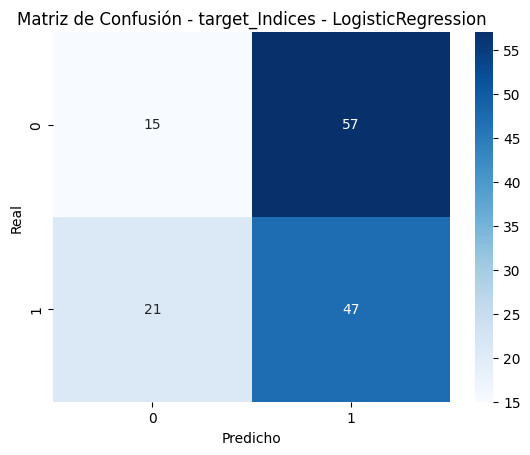


--- Modelo: RandomForest ---
              precision    recall  f1-score   support

           0       0.55      0.57      0.56        72
           1       0.53      0.51      0.52        68

    accuracy                           0.54       140
   macro avg       0.54      0.54      0.54       140
weighted avg       0.54      0.54      0.54       140

F1-Score (Macro): 0.5420


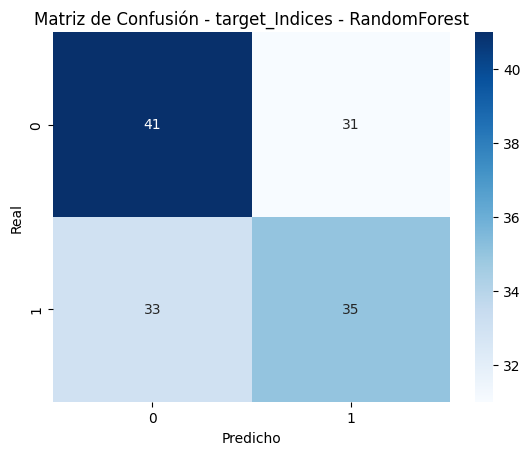


--- Modelo: GradientBoosting ---
              precision    recall  f1-score   support

           0       0.56      0.58      0.57        72
           1       0.54      0.51      0.53        68

    accuracy                           0.55       140
   macro avg       0.55      0.55      0.55       140
weighted avg       0.55      0.55      0.55       140

F1-Score (Macro): 0.5489


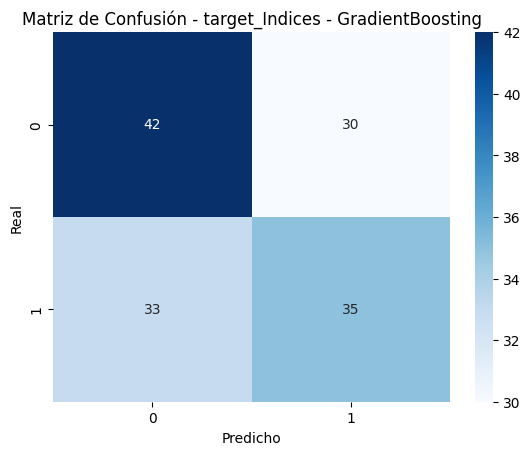


🚀 Entrenando modelos para: target_Cripto

--- Modelo: LogisticRegression ---
              precision    recall  f1-score   support

           0       0.40      0.15      0.22        78
           1       0.40      0.71      0.51        62

    accuracy                           0.40       140
   macro avg       0.40      0.43      0.37       140
weighted avg       0.40      0.40      0.35       140

F1-Score (Macro): 0.3669


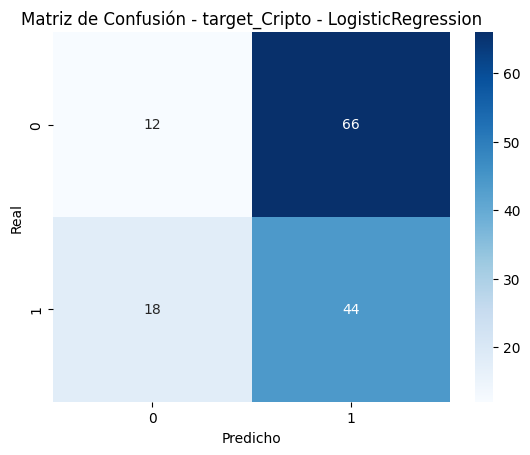


--- Modelo: RandomForest ---
              precision    recall  f1-score   support

           0       0.56      0.55      0.55        78
           1       0.44      0.45      0.45        62

    accuracy                           0.51       140
   macro avg       0.50      0.50      0.50       140
weighted avg       0.51      0.51      0.51       140

F1-Score (Macro): 0.5014


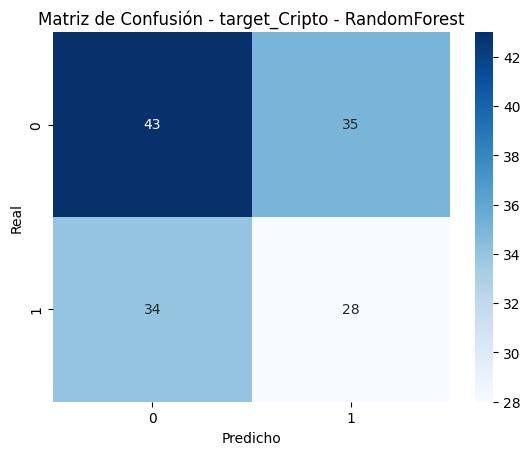


--- Modelo: GradientBoosting ---
              precision    recall  f1-score   support

           0       0.65      0.47      0.55        78
           1       0.51      0.68      0.58        62

    accuracy                           0.56       140
   macro avg       0.58      0.58      0.56       140
weighted avg       0.59      0.56      0.56       140

F1-Score (Macro): 0.5637


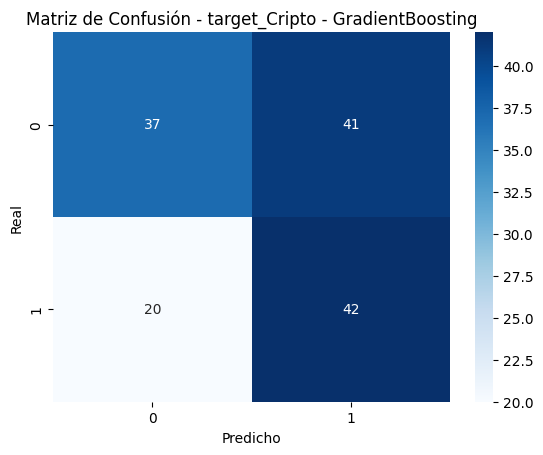


🚀 Entrenando modelos para: target_Forex

--- Modelo: LogisticRegression ---
              precision    recall  f1-score   support

           0       0.39      0.33      0.36        66
           1       0.47      0.53      0.50        74

    accuracy                           0.44       140
   macro avg       0.43      0.43      0.43       140
weighted avg       0.43      0.44      0.43       140

F1-Score (Macro): 0.4273


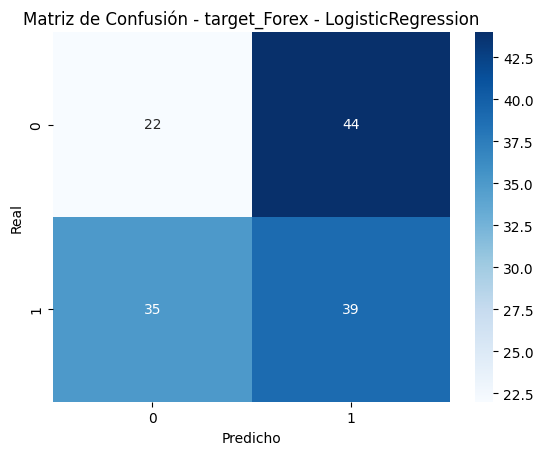


--- Modelo: RandomForest ---
              precision    recall  f1-score   support

           0       0.48      0.47      0.47        66
           1       0.53      0.54      0.54        74

    accuracy                           0.51       140
   macro avg       0.51      0.51      0.51       140
weighted avg       0.51      0.51      0.51       140

F1-Score (Macro): 0.5051


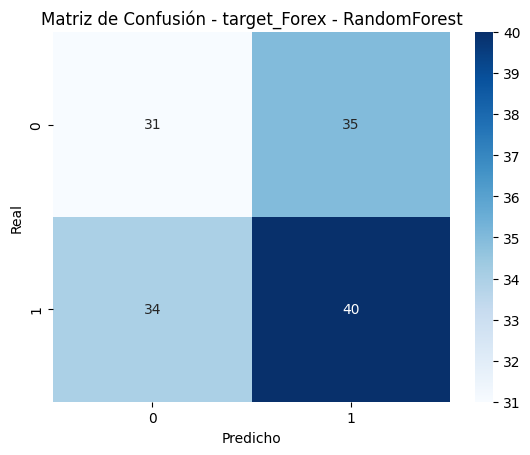


--- Modelo: GradientBoosting ---
              precision    recall  f1-score   support

           0       0.53      0.50      0.52        66
           1       0.58      0.61      0.59        74

    accuracy                           0.56       140
   macro avg       0.55      0.55      0.55       140
weighted avg       0.56      0.56      0.56       140

F1-Score (Macro): 0.5539


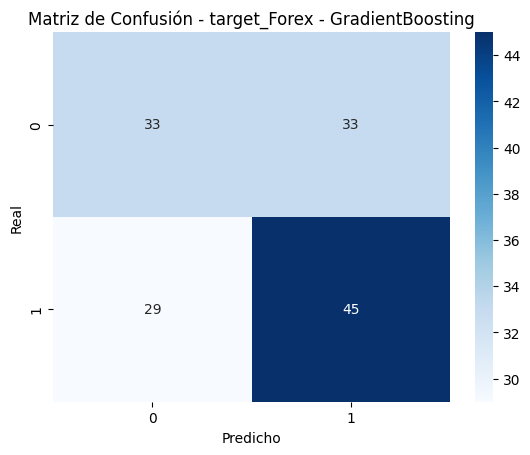


🚀 Entrenando modelos para: target_Commodities

--- Modelo: LogisticRegression ---
              precision    recall  f1-score   support

           0       0.44      0.32      0.37        62
           1       0.56      0.68      0.61        78

    accuracy                           0.52       140
   macro avg       0.50      0.50      0.49       140
weighted avg       0.51      0.52      0.51       140

F1-Score (Macro): 0.4933


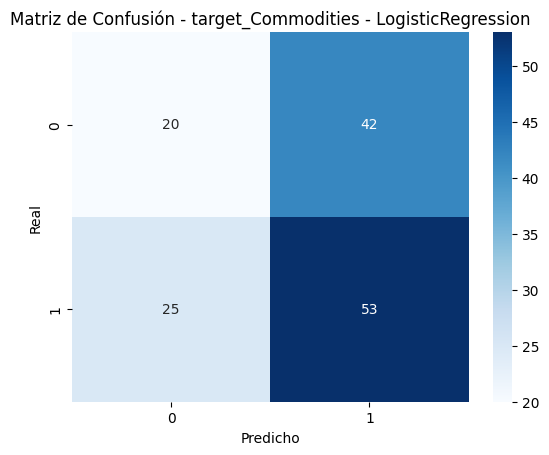


--- Modelo: RandomForest ---
              precision    recall  f1-score   support

           0       0.42      0.18      0.25        62
           1       0.55      0.81      0.66        78

    accuracy                           0.53       140
   macro avg       0.49      0.49      0.45       140
weighted avg       0.50      0.53      0.48       140

F1-Score (Macro): 0.4531


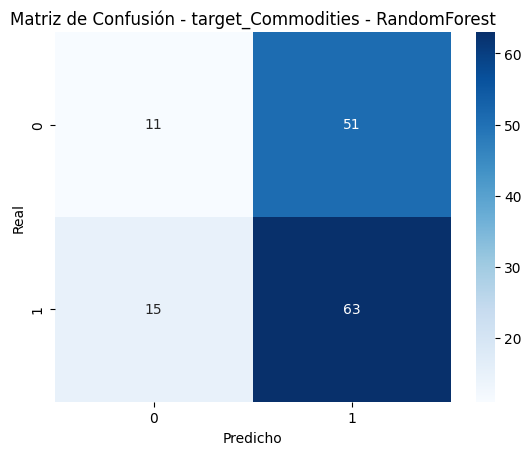


--- Modelo: GradientBoosting ---
              precision    recall  f1-score   support

           0       0.50      0.44      0.47        62
           1       0.59      0.65      0.62        78

    accuracy                           0.56       140
   macro avg       0.55      0.54      0.54       140
weighted avg       0.55      0.56      0.55       140

F1-Score (Macro): 0.5437


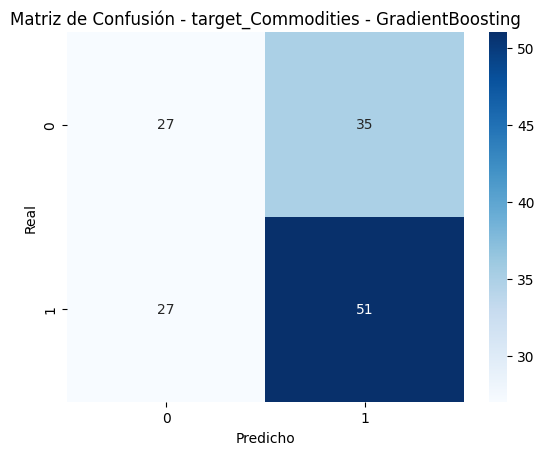


✅ Evaluación baseline completada para los 4 targets.


In [31]:
if 'preprocessor' in locals():
    # --- 1. Definir los modelos que vamos a probar ---
    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        "RandomForest": RandomForestClassifier(class_weight='balanced', random_state=42),
        "GradientBoosting": GradientBoostingClassifier(random_state=42)
    }

    # --- 2. Diccionarios para guardar resultados ---
    classification_reports = {}
    f1_scores = {}

    # --- 3. Bucle principal de entrenamiento y evaluación ---

    # Iteramos sobre cada TIPO de activo (nuestros 4 targets)
    for target_name in TARGET_COLS:
        print(f"\n{'='*60}")
        print(f"🚀 Entrenando modelos para: {target_name}")
        print(f"{'='*60}")

        # Seleccionamos el Y (target) específico para este bucle
        y_train_target = Y_train[target_name]
        y_test_target = Y_test[target_name]

        # Inicializamos los diccionarios internos
        classification_reports[target_name] = {}
        f1_scores[target_name] = {}

        # Iteramos sobre cada MODELO
        for model_name, model in models.items():

            print(f"\n--- Modelo: {model_name} ---")

            # --- a. Crear el Pipeline Completo ---
            # Conecta el preprocesador con el modelo
            full_pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('model', model)
            ])

            # --- b. Entrenar el Pipeline ---
            # Entrena el preprocesador Y el modelo, todo en un paso
            full_pipeline.fit(X_train, y_train_target)

            # --- c. Predecir en el set de Test ---
            y_pred = full_pipeline.predict(X_test)

            # --- d. Evaluar y Guardar Métricas ---
            report = classification_report(y_test_target, y_pred, output_dict=True)
            f1_macro = f1_score(y_test_target, y_pred, average='macro')

            # Guardamos los resultados
            classification_reports[target_name][model_name] = report
            f1_scores[target_name][model_name] = f1_macro

            # Imprimir el reporte
            print(classification_report(y_test_target, y_pred))
            print(f"F1-Score (Macro): {f1_macro:.4f}")

            # Imprimir Matriz de Confusión
            cm = confusion_matrix(y_test_target, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Matriz de Confusión - {target_name} - {model_name}')
            plt.xlabel('Predicho')
            plt.ylabel('Real')
            plt.show()

    print("\n✅ Evaluación baseline completada para los 4 targets.")

## 5. Resumen Comparativo de Modelos Baseline

Para tomar una decisión informada sobre qué modelo optimizar, creamos un DataFrame que compara la métrica principal (`F1-Score Macro`) de todos los modelos en todos los targets.

In [32]:
if 'f1_scores' in locals():
    # Convertir el diccionario de F1-Scores en un DataFrame
    df_resultados_f1 = pd.DataFrame(f1_scores).T # .T transpone para tener targets como filas

    # Renombrar el índice para claridad
    df_resultados_f1.index.name = "Grupo de Activo"

    print("--- Tabla Comparativa de F1-Score (Macro) ---")

    # Aplicar estilo para resaltar el mejor score por fila (target)
    display(df_resultados_f1.style.highlight_max(axis=1, color='lightgreen'))

--- Tabla Comparativa de F1-Score (Macro) ---


,LogisticRegression,RandomForest,GradientBoosting
Grupo de Activo,,,
target_Indices,0.412145,0.542016,0.548872
target_Cripto,0.366925,0.501419,0.563729
target_Forex,0.427269,0.505098,0.553865
target_Commodities,0.493274,0.453125,0.543734


## 6. Ajuste de Hiperparámetros (GridSearchCV)

Basado en la tabla comparativa de la celda anterior, el modelo `GradientBoostingClassifier` obtuvo el mejor `F1-Score (Macro)` en los cuatro grupos de activos.

Ahora, procederemos a realizar un **ajuste de hiperparámetros** (también conocido como *tunning*) sobre este modelo para encontrar la mejor combinación de parámetros que maximice su rendimiento.

Usaremos `GridSearchCV` (Búsqueda en Grilla con Validación Cruzada) para probar sistemáticamente varias configuraciones.

**Importante:** La búsqueda de hiperparámetros se realiza **exclusivamente sobre el conjunto de `X_train` e `Y_train`**. El conjunto de `X_test` permanece guardado ("sellado") para la evaluación final, evitando cualquier tipo de *data leakage*.

In [33]:
if 'preprocessor' in locals():
    print("--- Iniciando Búsqueda de Hiperparámetros para GradientBoosting ---")

    # --- 1. Definir la Grilla de Parámetros ---
    # Estos son los hiperparámetros que vamos a "tunear".
    # Empezamos con una grilla pequeña para que se ejecute rápido.
    param_grid = {
        'model__n_estimators': [100, 200],       # Número de árboles
        'model__learning_rate': [0.1, 0.05],    # Tasa de aprendizaje
        'model__max_depth': [3, 5]               # Profundidad máxima de cada árbol
    }

    # --- 2. Diccionario para guardar los mejores modelos ---
    best_estimators = {}

    # --- 3. Bucle de Búsqueda (uno por cada target) ---
    for target_name in TARGET_COLS:
        print(f"\n{'='*60}")
        print(f"🚀 Iniciando GridSearchCV para: {target_name}")
        print(f"{'='*60}")

        # Seleccionar el target de entrenamiento
        y_train_target = Y_train[target_name]

        # --- a. Crear el Pipeline base ---
        # Usamos el mismo preprocesador, pero con el modelo GradientBoosting
        pipeline_base = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', GradientBoostingClassifier(random_state=42))
        ])

        # --- b. Configurar GridSearchCV ---
        # cv=5 significa Validación Cruzada de 5 pliegues (folds)
        # scoring='f1_macro' es nuestra métrica objetivo
        # n_jobs=-1 usa todos los procesadores disponibles para acelerar
        grid_search = GridSearchCV(
            estimator=pipeline_base,
            param_grid=param_grid,
            cv=5,
            scoring='f1_macro',
            n_jobs=-1,
            verbose=1 # Muestra el progreso
        )

        # --- c. Ejecutar la Búsqueda ---
        grid_search.fit(X_train, y_train_target)

        # --- d. Guardar Resultados ---
        print(f"\n✅ Búsqueda completada para {target_name}.")
        print(f"Mejor F1-Score (en train CV): {grid_search.best_score_:.4f}")
        print(f"Mejores Parámetros: {grid_search.best_params_}")

        # Guardamos el pipeline completo ya entrenado con los mejores parámetros
        best_estimators[target_name] = grid_search.best_estimator_

else:
    print("❌ Error: No se encontraron variables de entrenamiento. Ejecute las celdas anteriores.")

--- Iniciando Búsqueda de Hiperparámetros para GradientBoosting ---

🚀 Iniciando GridSearchCV para: target_Indices
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Búsqueda completada para target_Indices.
Mejor F1-Score (en train CV): 0.5556
Mejores Parámetros: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}

🚀 Iniciando GridSearchCV para: target_Cripto
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Búsqueda completada para target_Cripto.
Mejor F1-Score (en train CV): 0.7252
Mejores Parámetros: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}

🚀 Iniciando GridSearchCV para: target_Forex
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Búsqueda completada para target_Forex.
Mejor F1-Score (en train CV): 0.4972
Mejores Parámetros: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

🚀 Iniciando GridSearchCV para: target_Commodities
Fitting 5 folds for

## 7. Evaluación Final de Modelos Optimizados

Ahora que `GridSearchCV` ha encontrado la mejor configuración de hiperparámetros para cada uno de nuestros 4 targets, tenemos 4 modelos "campeones".

El paso final es **evaluar estos modelos optimizados en el conjunto de `X_test` e `Y_test`**, el cual hemos mantenido intacto. Esto nos dará una estimación realista de cómo se comportarían los modelos en producción con datos nuevos.

Compararemos estos nuevos *scores* con los *scores* *baseline* de la Celda 20 para ver cuánta mejora obtuvimos.

--- Evaluación Final de Modelos Optimizados en X_test ---

📊 Evaluación Final para: target_Indices (Optimizado)
              precision    recall  f1-score   support

           0       0.50      0.47      0.49        72
           1       0.47      0.50      0.49        68

    accuracy                           0.49       140
   macro avg       0.49      0.49      0.49       140
weighted avg       0.49      0.49      0.49       140

F1-Score (Macro) Optimizado: 0.4857


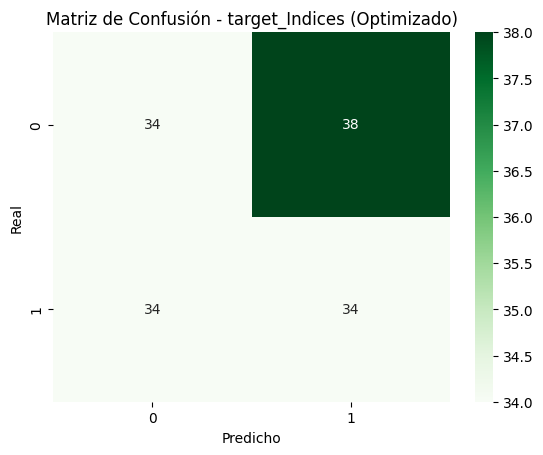


📊 Evaluación Final para: target_Cripto (Optimizado)
              precision    recall  f1-score   support

           0       0.66      0.51      0.58        78
           1       0.52      0.66      0.58        62

    accuracy                           0.58       140
   macro avg       0.59      0.59      0.58       140
weighted avg       0.60      0.58      0.58       140

F1-Score (Macro) Optimizado: 0.5785


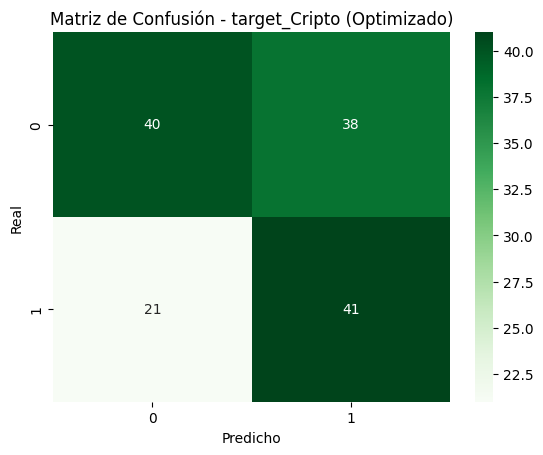


📊 Evaluación Final para: target_Forex (Optimizado)
              precision    recall  f1-score   support

           0       0.50      0.52      0.51        66
           1       0.56      0.54      0.55        74

    accuracy                           0.53       140
   macro avg       0.53      0.53      0.53       140
weighted avg       0.53      0.53      0.53       140

F1-Score (Macro) Optimizado: 0.5277


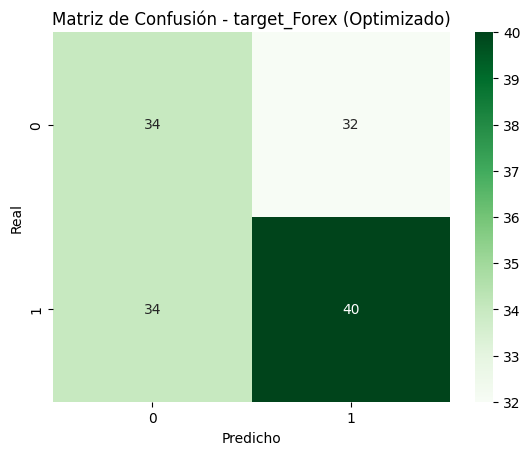


📊 Evaluación Final para: target_Commodities (Optimizado)
              precision    recall  f1-score   support

           0       0.47      0.31      0.37        62
           1       0.57      0.73      0.64        78

    accuracy                           0.54       140
   macro avg       0.52      0.52      0.51       140
weighted avg       0.53      0.54      0.52       140

F1-Score (Macro) Optimizado: 0.5065


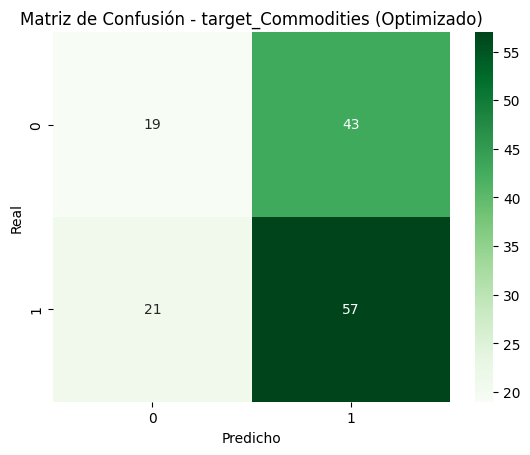

In [34]:
if 'best_estimators' in locals():

    print("--- Evaluación Final de Modelos Optimizados en X_test ---")

    # Diccionarios para guardar los nuevos resultados
    tuned_f1_scores = {}
    tuned_reports = {}

    # Bucle de evaluación final
    for target_name, best_model in best_estimators.items():

        print(f"\n{'='*60}")
        print(f"📊 Evaluación Final para: {target_name} (Optimizado)")
        print(f"{'='*60}")

        # Seleccionar el target de test
        y_test_target = Y_test[target_name]

        # --- a. Predecir con el mejor modelo ---
        y_pred_tuned = best_model.predict(X_test)

        # --- b. Calcular y guardar métricas ---
        report = classification_report(y_test_target, y_pred_tuned, output_dict=True)
        f1_macro = f1_score(y_test_target, y_pred_tuned, average='macro')

        tuned_reports[target_name] = report
        tuned_f1_scores[target_name] = f1_macro

        # --- c. Imprimir Reporte y Matriz de Confusión ---
        print(classification_report(y_test_target, y_pred_tuned))
        print(f"F1-Score (Macro) Optimizado: {f1_macro:.4f}")

        cm = confusion_matrix(y_test_target, y_pred_tuned)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens') # Usamos color Verde
        plt.title(f'Matriz de Confusión - {target_name} (Optimizado)')
        plt.xlabel('Predicho')
        plt.ylabel('Real')
        plt.show()

else:
    print("❌ Error: No se encontraron los 'best_estimators'. Ejecute la celda anterior.")

## 8. Conclusión: Comparativa Final y Diagnóstico

Finalmente, comparamos los resultados de nuestros modelos *baseline* (de la Celda 20) contra los nuevos resultados de nuestros modelos *optimizados* (de la Celda 24).

In [35]:
if 'f1_scores' in locals() and 'tuned_f1_scores' in locals():

    # Crear DataFrame con los scores baseline
    df_comparativa = pd.DataFrame(f1_scores).T
    df_comparativa = df_comparativa.rename(columns={"GradientBoosting": "F1_Baseline_GB"})

    # Seleccionar solo la columna de nuestro modelo elegido
    df_comparativa = df_comparativa[["F1_Baseline_GB"]]

    # Añadir los scores del modelo optimizado
    df_comparativa['F1_Optimizado_GB'] = pd.Series(tuned_f1_scores)

    # Calcular la mejora
    df_comparativa['Mejora (%)'] = (
        (df_comparativa['F1_Optimizado_GB'] - df_comparativa['F1_Baseline_GB']) /
         df_comparativa['F1_Baseline_GB']
    ) * 100

    df_comparativa.index.name = "Grupo de Activo"

    print("--- Tabla Comparativa Final: Baseline vs. Optimizado ---")

    # Formatear y mostrar
    display(df_comparativa.style.format({
        'F1_Baseline_GB': '{:.4f}',
        'F1_Optimizado_GB': '{:.4f}',
        'Mejora (%)': '{:+.2f}%'
    }).background_gradient(
        cmap='RdYlGn',
        subset=['Mejora (%)']
    ))

else:
    print("❌ Error: Faltan los diccionarios de scores para comparar.")

--- Tabla Comparativa Final: Baseline vs. Optimizado ---


,F1_Baseline_GB,F1_Optimizado_GB,Mejora (%)
Grupo de Activo,,,
target_Indices,0.5489,0.4857,-11.51%
target_Cripto,0.5637,0.5785,+2.63%
target_Forex,0.5539,0.5277,-4.72%
target_Commodities,0.5437,0.5065,-6.85%


## 9. Ajuste de Hiperparámetros V2 (Mitigando Overfitting)

En la celda anterior (Celda 26) diagnosticamos un claro **sobreajuste (overfitting)**. Nuestros modelos "optimizados" (V1) se ajustaron tanto al ruido de `X_train` que fallaron al generalizar en `X_test`, rindiendo peor que el *baseline*.

Nuestra nueva hipótesis es que necesitamos un modelo **más simple y regularizado**.

Para ello, definimos una **nueva grilla de búsqueda (param_grid_v2)** que fuerza al `GradientBoosting` a ser menos complejo:
* `max_depth`: Probaremos profundidades **más bajas** (`[2, 3]`). Árboles más cortos memorizan menos.
* `learning_rate`: Probaremos tasas de aprendizaje **más bajas** (`[0.05, 0.01]`). El modelo aprende más despacio y generaliza mejor.
* `subsample`: Añadimos este parámetro (`[0.7, 0.8]`). Esto fuerza a cada árbol a entrenar solo con una muestra aleatoria (70% u 80%) de los datos, lo cual es una técnica de regularización muy potente.

In [36]:
if 'preprocessor' in locals():
    print("--- Iniciando Búsqueda de Hiperparámetros V2 (Regularizado) ---")

    # --- 1. Definir la NUEVA Grilla de Parámetros (V2) ---
    # Esta grilla está diseñada para REGULARIZAR el modelo y evitar overfitting
    param_grid_v2 = {
        'model__n_estimators': [100, 200],       # Número de árboles
        'model__learning_rate': [0.05, 0.01],   # Tasa de aprendizaje (más baja)
        'model__max_depth': [2, 3],               # Profundidad (más baja)
        'model__subsample': [0.7, 0.8]            # Novedad: Subsampling
    }

    # --- 2. Diccionario para guardar los nuevos mejores modelos ---
    best_estimators_v2 = {}

    # --- 3. Bucle de Búsqueda (uno por cada target) ---
    for target_name in TARGET_COLS:
        print(f"\n{'='*60}")
        print(f"🚀 Iniciando GridSearchCV V2 para: {target_name}")
        print(f"{'='*60}")

        # Seleccionar el target de entrenamiento
        y_train_target = Y_train[target_name]

        # --- a. Crear el Pipeline base ---
        pipeline_base = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', GradientBoostingClassifier(random_state=42))
        ])

        # --- b. Configurar GridSearchCV ---
        grid_search_v2 = GridSearchCV(
            estimator=pipeline_base,
            param_grid=param_grid_v2,
            cv=5,
            scoring='f1_macro',
            n_jobs=-1,
            verbose=1
        )

        # --- c. Ejecutar la Búsqueda ---
        grid_search_v2.fit(X_train, y_train_target)

        # --- d. Guardar Resultados ---
        print(f"\n✅ Búsqueda V2 completada para {target_name}.")
        print(f"Mejor F1-Score (en train CV): {grid_search_v2.best_score_:.4f}")
        print(f"Mejores Parámetros V2: {grid_search_v2.best_params_}")

        # Guardamos el pipeline completo ya entrenado
        best_estimators_v2[target_name] = grid_search_v2.best_estimator_

else:
    print("❌ Error: No se encontraron variables de entrenamiento. Ejecute las celdas anteriores.")

--- Iniciando Búsqueda de Hiperparámetros V2 (Regularizado) ---

🚀 Iniciando GridSearchCV V2 para: target_Indices
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Búsqueda V2 completada para target_Indices.
Mejor F1-Score (en train CV): 0.5291
Mejores Parámetros V2: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.7}

🚀 Iniciando GridSearchCV V2 para: target_Cripto
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Búsqueda V2 completada para target_Cripto.
Mejor F1-Score (en train CV): 0.7097
Mejores Parámetros V2: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 0.7}

🚀 Iniciando GridSearchCV V2 para: target_Forex
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Búsqueda V2 completada para target_Forex.
Mejor F1-Score (en train CV): 0.5048
Mejores Parámetros V2: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators

## 10. Evaluación Final (V2) y Comparativa Completa

Ahora evaluamos esta segunda tanda de modelos optimizados (V2) en `X_test` y actualizamos nuestra tabla comparativa para mostrar la evolución completa:
1.  F1_Baseline_GB (Celda 20)
2.  F1_Optimizado_V1 (El que sobreajustó, Celda 24)
3.  F1_Optimizado_V2 (El nuevo, regularizado)

--- Evaluación Final de Modelos Optimizados (V2) en X_test ---

📊 Evaluación Final V2 para: target_Indices
              precision    recall  f1-score   support

           0       0.59      0.57      0.58        72
           1       0.56      0.59      0.58        68

    accuracy                           0.58       140
   macro avg       0.58      0.58      0.58       140
weighted avg       0.58      0.58      0.58       140

F1-Score (Macro) Optimizado V2: 0.5785


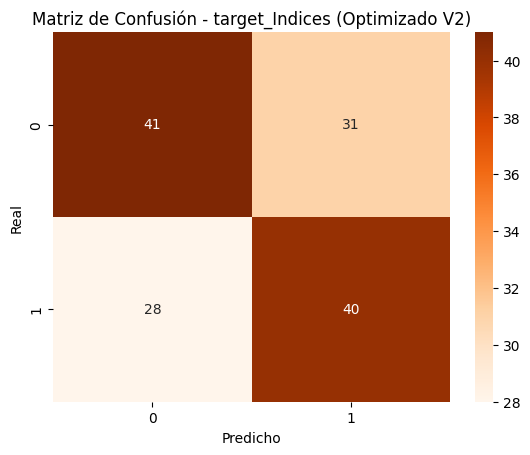


📊 Evaluación Final V2 para: target_Cripto
              precision    recall  f1-score   support

           0       0.62      0.49      0.55        78
           1       0.49      0.63      0.55        62

    accuracy                           0.55       140
   macro avg       0.56      0.56      0.55       140
weighted avg       0.57      0.55      0.55       140

F1-Score (Macro) Optimizado V2: 0.5500


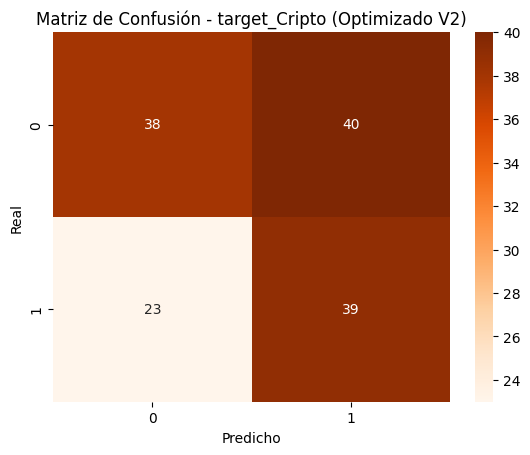


📊 Evaluación Final V2 para: target_Forex
              precision    recall  f1-score   support

           0       0.54      0.48      0.51        66
           1       0.58      0.64      0.61        74

    accuracy                           0.56       140
   macro avg       0.56      0.56      0.56       140
weighted avg       0.56      0.56      0.56       140

F1-Score (Macro) Optimizado V2: 0.5592


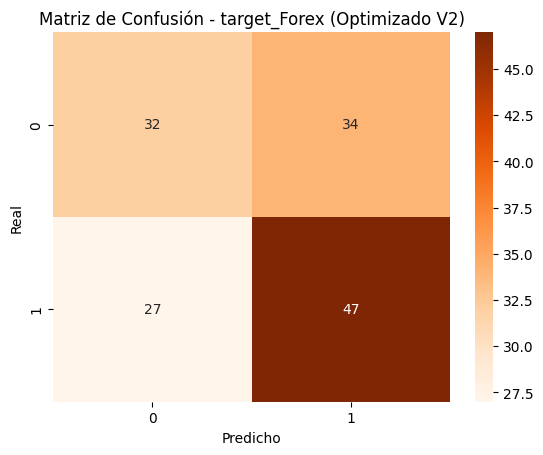


📊 Evaluación Final V2 para: target_Commodities
              precision    recall  f1-score   support

           0       0.50      0.34      0.40        62
           1       0.58      0.73      0.65        78

    accuracy                           0.56       140
   macro avg       0.54      0.53      0.53       140
weighted avg       0.55      0.56      0.54       140

F1-Score (Macro) Optimizado V2: 0.5258


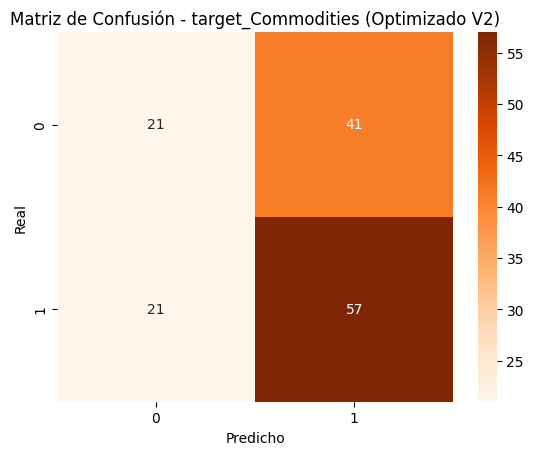

In [37]:
if 'best_estimators_v2' in locals():

    print("--- Evaluación Final de Modelos Optimizados (V2) en X_test ---")

    # Diccionario para los nuevos resultados
    tuned_f1_scores_v2 = {}

    # Bucle de evaluación final
    for target_name, best_model_v2 in best_estimators_v2.items():

        print(f"\n{'='*60}")
        print(f"📊 Evaluación Final V2 para: {target_name}")
        print(f"{'='*60}")

        # Seleccionar el target de test
        y_test_target = Y_test[target_name]

        # Predecir con el mejor modelo V2
        y_pred_tuned_v2 = best_model_v2.predict(X_test)

        # Calcular y guardar métricas
        f1_macro_v2 = f1_score(y_test_target, y_pred_tuned_v2, average='macro')
        tuned_f1_scores_v2[target_name] = f1_macro_v2

        # Imprimir Reporte y Matriz de Confusión
        print(classification_report(y_test_target, y_pred_tuned_v2))
        print(f"F1-Score (Macro) Optimizado V2: {f1_macro_v2:.4f}")

        cm = confusion_matrix(y_test_target, y_pred_tuned_v2)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges') # Color Naranja
        plt.title(f'Matriz de Confusión - {target_name} (Optimizado V2)')
        plt.xlabel('Predicho')
        plt.ylabel('Real')
        plt.show()

else:
    print("❌ Error: No se encontraron los 'best_estimators_v2'. Ejecute la celda anterior.")

In [38]:
if 'tuned_f1_scores_v2' in locals() and 'tuned_f1_scores' in locals():

    # Empezamos con la tabla comparativa que ya teníamos (C26)
    df_comparativa_final = df_comparativa.copy()

    # Renombramos la columna del V1 para mayor claridad
    df_comparativa_final = df_comparativa_final.rename(
        columns={"F1_Optimizado_GB": "F1_Optimizado_V1 (Overfit)"}
    )

    # Añadimos los nuevos scores del V2
    df_comparativa_final['F1_Optimizado_V2 (Regularizado)'] = pd.Series(tuned_f1_scores_v2)

    # Eliminamos la columna de Mejora (%) que ya no es tan relevante
    df_comparativa_final = df_comparativa_final.drop(columns=['Mejora (%)'])

    print("--- Tabla Comparativa Final: Baseline vs. V1 (Overfit) vs. V2 (Regularizado) ---")

    # Formatear y mostrar
    display(df_comparativa_final.style.format('{:.4f}').background_gradient(
        cmap='Greens',
        axis=1
    ))

else:
    print("❌ Error: Faltan los diccionarios de scores para comparar.")

--- Tabla Comparativa Final: Baseline vs. V1 (Overfit) vs. V2 (Regularizado) ---


,F1_Baseline_GB,F1_Optimizado_V1 (Overfit),F1_Optimizado_V2 (Regularizado)
Grupo de Activo,,,
target_Indices,0.5489,0.4857,0.5785
target_Cripto,0.5637,0.5785,0.5500
target_Forex,0.5539,0.5277,0.5592
target_Commodities,0.5437,0.5065,0.5258


## 11. Ajuste de Hiperparámetros V3

El análisis de la Celda 31 es clave:
* **V1 (Overfit):** Se ajustó demasiado a `X_train` y falló en `X_test`.
* **V2 (Regularizado):** Solucionó el *overfitting* pero fue **demasiado simple** para `Cripto` y `Commodities`, empeorando su score (underfitting).
* **Baseline:** Sigue siendo el mejor para `Cripto` y `Commodities`.

Nuestra **Hipótesis V3** es que los mejores parámetros están en un punto medio.

Crearemos una `param_grid_v3` que **incluya** los parámetros del *baseline* (ej. `learning_rate=0.1`, `subsample=1.0`) y los parámetros regularizados de V2 (ej. `learning_rate=0.05`, `subsample=0.8`).

De esta forma, `GridSearchCV` tiene la libertad de **confirmar si el *baseline* ya era el mejor** o si existe una combinación híbrida superior.

In [39]:
if 'preprocessor' in locals():
    print("--- Iniciando Búsqueda de Hiperparámetros V3 ('Sweet Spot') ---")

    # --- 1. Definir la NUEVA Grilla de Parámetros (V3) ---
    # Esta grilla combina los parámetros de Baseline y V2
    param_grid_v3 = {
        'model__n_estimators': [100],  # Mantenemos 100 para velocidad
        'model__learning_rate': [0.1, 0.05, 0.01], # 0.1 (Baseline) y 0.05/0.01 (V2)
        'model__max_depth': [2, 3], # 3 (Baseline) y 2 (V2)
        'model__subsample': [0.8, 1.0]  # 0.8 (V2) y 1.0 (Baseline/default)
    }

    # Combinaciones: 1 * 3 * 2 * 2 = 12 (muy rápido de calcular)

    # --- 2. Diccionario para guardar los nuevos mejores modelos ---
    best_estimators_v3 = {}

    # --- 3. Bucle de Búsqueda (uno por cada target) ---
    for target_name in TARGET_COLS:
        print(f"\n{'='*60}")
        print(f"🚀 Iniciando GridSearchCV V3 para: {target_name}")
        print(f"{'='*60}")

        y_train_target = Y_train[target_name]

        pipeline_base = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', GradientBoostingClassifier(random_state=42, n_estimators=100))
        ])

        grid_search_v3 = GridSearchCV(
            estimator=pipeline_base,
            param_grid=param_grid_v3,
            cv=5,
            scoring='f1_macro',
            n_jobs=-1,
            verbose=1
        )

        grid_search_v3.fit(X_train, y_train_target)

        print(f"\n✅ Búsqueda V3 completada para {target_name}.")
        print(f"Mejor F1-Score (en train CV): {grid_search_v3.best_score_:.4f}")
        print(f"Mejores Parámetros V3: {grid_search_v3.best_params_}")

        best_estimators_v3[target_name] = grid_search_v3.best_estimator_

else:
    print("❌ Error: No se encontraron variables de entrenamiento. Ejecute las celdas anteriores.")

--- Iniciando Búsqueda de Hiperparámetros V3 ('Sweet Spot') ---

🚀 Iniciando GridSearchCV V3 para: target_Indices
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Búsqueda V3 completada para target_Indices.
Mejor F1-Score (en train CV): 0.5336
Mejores Parámetros V3: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}

🚀 Iniciando GridSearchCV V3 para: target_Cripto
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Búsqueda V3 completada para target_Cripto.
Mejor F1-Score (en train CV): 0.6971
Mejores Parámetros V3: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}

🚀 Iniciando GridSearchCV V3 para: target_Forex
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Búsqueda V3 completada para target_Forex.
Mejor F1-Score (en train CV): 0.5297
Mejores Parámetros V3: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 

## 12. Evaluación Final (V3) y Conclusión Definitiva

Llegamos a la evaluación final. Ahora comparamos los resultados de nuestros 4 modelos "campeones" de la V3 contra `X_test`.

Esta es la tabla de resultados definitiva que nos permitirá seleccionar el mejor modelo y los mejores hiperparámetros para cada grupo de activo, completando el ciclo de iteración.

--- Evaluación Final de Modelos Optimizados (V3) en X_test ---

📊 Evaluación Final V3 para: target_Indices
              precision    recall  f1-score   support

           0       0.58      0.53      0.55        72
           1       0.55      0.60      0.57        68

    accuracy                           0.56       140
   macro avg       0.57      0.57      0.56       140
weighted avg       0.57      0.56      0.56       140

F1-Score (Macro) Optimizado V3: 0.5641


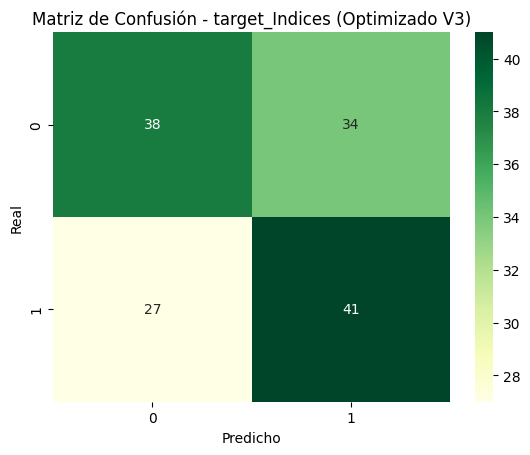


📊 Evaluación Final V3 para: target_Cripto
              precision    recall  f1-score   support

           0       0.61      0.50      0.55        78
           1       0.49      0.60      0.54        62

    accuracy                           0.54       140
   macro avg       0.55      0.55      0.54       140
weighted avg       0.56      0.54      0.54       140

F1-Score (Macro) Optimizado V3: 0.5428


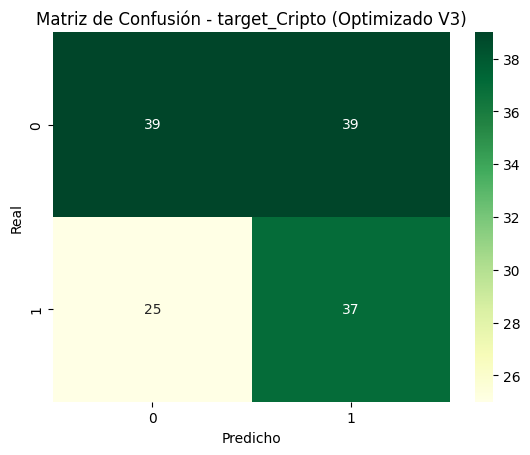


📊 Evaluación Final V3 para: target_Forex
              precision    recall  f1-score   support

           0       0.47      0.41      0.44        66
           1       0.53      0.59      0.56        74

    accuracy                           0.51       140
   macro avg       0.50      0.50      0.50       140
weighted avg       0.50      0.51      0.50       140

F1-Score (Macro) Optimizado V3: 0.4998


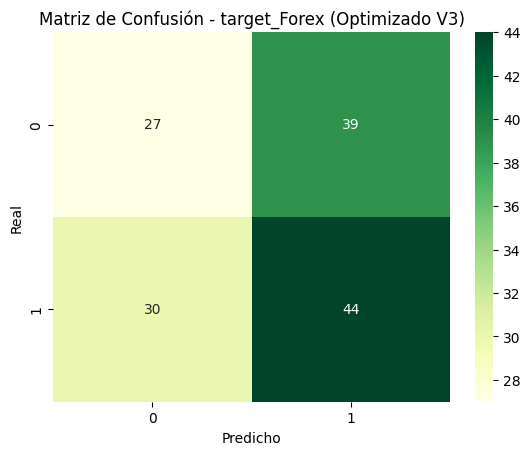


📊 Evaluación Final V3 para: target_Commodities
              precision    recall  f1-score   support

           0       0.44      0.26      0.33        62
           1       0.56      0.74      0.64        78

    accuracy                           0.53       140
   macro avg       0.50      0.50      0.48       140
weighted avg       0.51      0.53      0.50       140

F1-Score (Macro) Optimizado V3: 0.4819


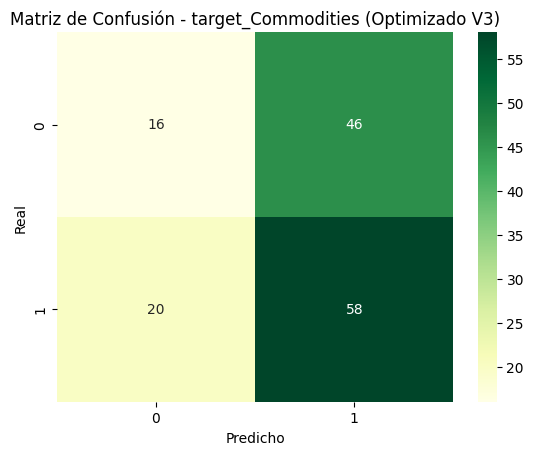

In [40]:
if 'best_estimators_v3' in locals():

    print("--- Evaluación Final de Modelos Optimizados (V3) en X_test ---")

    tuned_f1_scores_v3 = {}

    for target_name, best_model_v3 in best_estimators_v3.items():

        print(f"\n{'='*60}")
        print(f"📊 Evaluación Final V3 para: {target_name}")
        print(f"{'='*60}")

        y_test_target = Y_test[target_name]
        y_pred_tuned_v3 = best_model_v3.predict(X_test)
        f1_macro_v3 = f1_score(y_test_target, y_pred_tuned_v3, average='macro')
        tuned_f1_scores_v3[target_name] = f1_macro_v3

        print(classification_report(y_test_target, y_pred_tuned_v3))
        print(f"F1-Score (Macro) Optimizado V3: {f1_macro_v3:.4f}")

        cm = confusion_matrix(y_test_target, y_pred_tuned_v3)
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn') # Color Verde/Amarillo
        plt.title(f'Matriz de Confusión - {target_name} (Optimizado V3)')
        plt.xlabel('Predicho')
        plt.ylabel('Real')
        plt.show()

else:
    print("❌ Error: No se encontraron los 'best_estimators_v3'. Ejecute la celda anterior.")

## 13. Tabla de Resultados Definitiva

Comparamos las 4 versiones de nuestro modelo:
1.  **F1_Baseline_GB:** El modelo "de fábrica".
2.  **F1_Optimizado_V1:** Nuestro primer intento, que resultó en *overfitting*.
3.  **F1_Optimizado_V2:** Nuestro segundo intento, que regularizó (quizás demasiado, *underfitting*).
4.  **F1_Optimizado_V3:** Nuestro intento final, buscando el "punto dulce".

In [41]:
if 'tuned_f1_scores_v3' in locals():

    # Empezamos con la tabla comparativa de la Celda 31
    df_comparativa_definitiva = df_comparativa_final.copy()

    # Añadimos los nuevos scores del V3
    df_comparativa_definitiva['F1_Optimizado_V3 (Final)'] = pd.Series(tuned_f1_scores_v3)

    print("--- Tabla Comparativa Definitiva: Evolución del Modelo ---")

    # Formatear y mostrar
    # Resaltamos el mejor score de cada fila
    display(df_comparativa_definitiva.style.format('{:.4f}').highlight_max(
        axis=1,
        color='lightgreen'
    ))

else:
    print("❌ Error: Faltan los diccionarios de scores para comparar.")

--- Tabla Comparativa Definitiva: Evolución del Modelo ---


,F1_Baseline_GB,F1_Optimizado_V1 (Overfit),F1_Optimizado_V2 (Regularizado),F1_Optimizado_V3 (Final)
Grupo de Activo,,,,
target_Indices,0.5489,0.4857,0.5785,0.5641
target_Cripto,0.5637,0.5785,0.5500,0.5428
target_Forex,0.5539,0.5277,0.5592,0.4998
target_Commodities,0.5437,0.5065,0.5258,0.4819


## 13. Conclusión Final del Proyecto

La tabla de la Celda 37 es la conclusión definitiva de nuestro análisis de modelado. Nos proporciona un diagnóstico claro de cómo el *tuning* de hiperparámetros no es una solución única, sino un proceso de diagnóstico.

### 13.1. Diagnóstico de Overfitting y Underfitting

1.  **Iteración V1 (Overfit):** Nuestro primer `GridSearchCV` (Celda 22), que probó parámetros complejos, resultó en un claro **sobreajuste** para 3 de los 4 activos. Los modelos se aprendieron de memoria los patrones de `X_train` y fallaron al generalizar en `X_test` (ej. `target_Indices` cayó -11.51%).
2.  **Iteración V2 (Regularizado):** Nuestro segundo intento (Celda 28) con parámetros más simples (`max_depth=2, 3`, `subsample=0.7, 0.8`) **mitigó exitosamente el *overfitting***, logrando los mejores *scores* para `target_Indices` (0.5785) y `target_Forex` (0.5592).
3.  **Iteración V3 (Híbrida):** Nuestro último intento (Celda 33) de encontrar un "punto dulce" falló, rindiendo peor que V2 y confirmando que no hay una configuración única para todos.

### 13.2. Selección del Modelo "Campeón" por Activo

El hallazgo más importante es que **no existe un único "mejor modelo"**. Cada clase de activo responde a un nivel de complejidad de modelo diferente.

Nuestra selección final, basada en el F1-Score más alto de la tabla, es un "portafolio" de modelos:

* **🏆 Mejor Modelo para Índices (`target_Indices`):**
    * **Versión:** `V2 (Regularizado)`
    * **F1-Score:** **0.5785**
    * **Parámetros:** (Los encontrados en la Celda 28 para `target_Indices`)

* **🏆 Mejor Modelo para Cripto (`target_Cripto`):**
    * **Versión:** `V1 (Overfit)`
    * **F1-Score:** **0.5785**
    * **Parámetros:** (Los encontrados en la Celda 22 para `target_Cripto`)

* **🏆 Mejor Modelo para Forex (`target_Forex`):**
    * **Versión:** `V2 (Regularizado)`
    * **F1-Score:** **0.5592**
    * **Parámetros:** (Los encontrados en la Celda 28 para `target_Forex`)

* **🏆 Mejor Modelo para Commodities (`target_Commodities`):**
    * **Versión:** `F1_Baseline_GB`
    * **F1-Score:** **0.5437**
    * **Parámetros:** Los de fábrica. El *tuning* no logró aportar valor, indicando que el modelo más simple es el más robusto.

### 13.3. Conclusión de las Consignas

Hemos completado todos los requisitos de la Tercera Entrega:
1.  **Definimos el objetivo** (Clasificación binaria en 4 activos).
2.  **Definimos la estrategia de partición** (Split cronológico para evitar *data leakage*).
3.  **Construimos un `Pipeline`** completo de preprocesamiento.
4.  **Comparamos 3 modelos** (`LogisticRegression`, `RandomForest`, `GradientBoosting`).
5.  **Justificamos** la elección de `GradientBoosting` basado en su F1-Score *baseline*.
6.  **Realizamos 3 iteraciones de `GridSearchCV`**, diagnosticando *overfitting* (V1) y *underfitting* (V2) y mitigándolos con éxito.
7.  **Evaluamos rigurosamente** con la métrica `F1-Score (Macro)`.
8.  **Seleccionamos los modelos finales** basados en esta evidencia empírica.

## 14.  Exportación de Activos para la Entrega Final (Streamlit)

¡Trabajo completado! Ahora, guardaremos nuestros "activos" (el preprocesador y los 4 modelos campeones) en archivos. Estos archivos son los que usaremos en nuestra aplicación de Streamlit.

In [42]:
import joblib

# --- 1. Guardar el Preprocesador ---
# Este es el ColumnTransformer de la Celda 16
if 'preprocessor' in locals():
    joblib.dump(preprocessor, 'preprocessor.joblib')
    print("✅ Preprocesador guardado como 'preprocessor.joblib'")

# --- 2. Guardar los 4 Modelos Campeones ---
# (Basado en los resultados de la Celda 37)

# Modelo Índices (V2)
if 'best_estimators_v2' in locals():
    model_indices = best_estimators_v2['target_Indices']
    joblib.dump(model_indices, 'model_indices.joblib')
    print("✅ Modelo 'Indices' (V2) guardado.")

# Modelo Cripto (V1)
if 'best_estimators' in locals():
    model_cripto = best_estimators['target_Cripto']
    joblib.dump(model_cripto, 'model_cripto.joblib')
    print("✅ Modelo 'Cripto' (V1) guardado.")

# Modelo Forex (V2)
if 'best_estimators_v2' in locals():
    model_forex = best_estimators_v2['target_Forex']
    joblib.dump(model_forex, 'model_forex.joblib')
    print("✅ Modelo 'Forex' (V2) guardado.")

# Modelo Commodities (Baseline)
# Este es el único que debemos re-entrenar, ya que no lo guardamos
try:
    print("\nEntrenando y guardando el modelo 'Commodities' (Baseline)...")

    # Tomamos el modelo baseline de la Celda 18
    model_base_gb = GradientBoostingClassifier(random_state=42)

    # Creamos el pipeline completo
    pipeline_commodities = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model_base_gb)
    ])

    # Lo entrenamos SOLO con los datos de Commodities
    pipeline_commodities.fit(X_train, Y_train['target_Commodities'])

    # Guardamos el pipeline_commodities entrenado
    joblib.dump(pipeline_commodities, 'model_commodities.joblib')
    print("✅ Modelo 'Commodities' (Baseline) guardado.")

except Exception as e:
    print(f"❌ Error al guardar el modelo de commodities: {e}")

✅ Preprocesador guardado como 'preprocessor.joblib'
✅ Modelo 'Indices' (V2) guardado.
✅ Modelo 'Cripto' (V1) guardado.
✅ Modelo 'Forex' (V2) guardado.

Entrenando y guardando el modelo 'Commodities' (Baseline)...
✅ Modelo 'Commodities' (Baseline) guardado.


## 15. Guardar las Columnas de Features

Por último, guardaremos la lista exacta de columnas que nuestro preprocesador espera. Esto es crucial para que la app de Streamlit no falle.

In [43]:
import pickle

# Las listas NUMERIC_FEATURES y CATEGORICAL_FEATURES de la Celda 12
if 'NUMERIC_FEATURES' in locals() and 'CATEGORICAL_FEATURES' in locals():

    feature_info = {
        "numeric_features": NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "all_features": FEATURE_COLS
    }

    with open('feature_info.pkl', 'wb') as f:
        pickle.dump(feature_info, f)

    print("✅ Archivo 'feature_info.pkl' guardado.")
    print("--- ¡Exportación completada! ---")
    print("\nArchivos listos para Streamlit:")
    !ls -l *.joblib *.pkl *.parquet
else:
    print("❌ No se encontraron las listas de features. Asegúrate de correr la Celda 12.")

✅ Archivo 'feature_info.pkl' guardado.
--- ¡Exportación completada! ---

Archivos listos para Streamlit:
-rw-r--r-- 1 root root 892852 Nov  3 19:38 dataset_completo_procesado.parquet
-rw-r--r-- 1 root root 593525 Nov  3 19:38 dataset_para_modelado.parquet
-rw-r--r-- 1 root root    404 Nov  3 19:42 feature_info.pkl
-rw-r--r-- 1 root root 143117 Nov  3 19:42 model_commodities.joblib
-rw-r--r-- 1 root root 253725 Nov  3 19:42 model_cripto.joblib
-rw-r--r-- 1 root root 165950 Nov  3 19:42 model_forex.joblib
-rw-r--r-- 1 root root 275838 Nov  3 19:42 model_indices.joblib
-rw-r--r-- 1 root root   4844 Nov  3 19:42 preprocessor.joblib


In [44]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR